# Compressor Charts and Anti-Surge Control in NeqSim

This tutorial shows, step by step, how to:

1. Build a centrifugal compressor with a **performance chart** (speed lines for head and polytropic efficiency).
2. Add both operating-limit curves — a **surge curve** (low-flow stability limit) and a **stone wall
   curve** (high-flow choke limit) — and read each one back, including the surge/stone-wall flow at a
   given head and the distance-to-surge / distance-to-stone-wall margins.
3. Understand *why* a compressor surges at low flow (turndown, trips, start-up).
4. Build a complete **anti-surge recycle (spill-back) loop** in a `ProcessSystem` using the
   building blocks NeqSim provides:
   - a discharge **`Splitter`** that creates a forward branch and a recycle branch,
   - an **anti-surge `Calculator`** that decides how much gas to spill back,
   - an **anti-surge `ThrottlingValve`** that drops the recycle back to suction pressure,
   - a **`Recycle`** unit that closes the loop.
5. Run a **turndown sweep** and watch the recycle open automatically to keep the machine off surge.

> **Scope.** This is an educational model. Generated/illustrative charts are not vendor performance
> maps, and the steady-state anti-surge `Calculator` is not a tuned controller. Real anti-surge design
> needs vendor maps, dynamic/transient analysis, and a rotating-equipment review (API 617 / API 692).


## 1. Background: surge and anti-surge control

A centrifugal compressor develops **head** that rises as the inlet (actual, volumetric) flow falls.
Below a certain flow the flow through the impeller becomes unstable and momentarily reverses — this
violent oscillation is **surge**. It can damage seals, bearings and the rotor.

On a head-vs-flow chart, the locus of surge points across all speeds is the **surge line**. The
machine is safe to the **right** of this line and unsafe to the left.

```
  head
   ^                 ____ speed line (high speed)
   |   surge       /
   |   line  *----/----  operating point (safe, right of surge)
   |       /  \
   |      /    \___ speed line (low speed)
   |     /  UNSAFE
   |    / (left of surge)
   +-------------------------> actual inlet flow
```

**Anti-surge control** keeps the machine safe at low throughput by opening a **recycle (spill-back)**
line from discharge back to suction. Recycled gas adds to the *total* suction flow, so even when the
downstream demand is small, the compressor itself always sees enough flow to stay right of the surge
line (plus a safety margin called the **control line**).

NeqSim models exactly this topology:

```
  feed --> [Mixer] --> [Cooler] --> [Compressor] --> [Splitter] --(forward)--> downstream
             ^                          (chart +        |
             |                           surge)         (recycle branch, split index 1)
             |                                          |
          [Recycle] <-- [anti-surge Valve] <------------+
             ^                                          |
             |                          [anti-surge Calculator] reads the compressor
             |                          and sets the recycle branch flow
          (placeholder recycle stream)
```

## 2. Setup and imports

We use the direct Java access pattern (`from neqsim import jneqsim`).

In [1]:
from neqsim import jneqsim
import numpy as np
import matplotlib.pyplot as plt

# Thermo
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos

# Process model + equipment
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Stream = jneqsim.process.equipment.stream.Stream
Mixer = jneqsim.process.equipment.mixer.Mixer
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Compressor = jneqsim.process.equipment.compressor.Compressor
Splitter = jneqsim.process.equipment.splitter.Splitter
Calculator = jneqsim.process.equipment.util.Calculator
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Recycle = jneqsim.process.equipment.util.Recycle

print("NeqSim classes imported.")

NeqSim classes imported.


## 3. Feed gas and a helper to build the suction stream

A typical lean natural gas. We define a helper so we can rebuild the suction stream at different
throughputs during the turndown sweep. Flow is given in **MSm3/day** (million standard m³/day).

In [2]:
def make_feed_gas(flow_MSm3_day, t_C=24.0, p_bara=48.0):
    """Create a lean natural gas suction fluid at the given conditions and flow."""
    fluid = SystemSrkEos(273.15 + t_C, p_bara)
    fluid.addComponent("nitrogen", 1.205)
    fluid.addComponent("CO2", 1.340)
    fluid.addComponent("methane", 87.974)
    fluid.addComponent("ethane", 5.258)
    fluid.addComponent("propane", 3.283)
    fluid.addComponent("i-butane", 0.082)
    fluid.addComponent("n-butane", 0.487)
    fluid.addComponent("i-pentane", 0.056)
    fluid.addComponent("n-pentane", 0.053)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_MSm3_day, "MSm3/day")
    return fluid


SUCTION_P_BARA = 48.0  # compressor suction pressure (also the recycle valve outlet pressure)
HEALTHY_FLOW = 4.5     # MSm3/day -> a healthy point that sits comfortably on the chart

demo_fluid = make_feed_gas(HEALTHY_FLOW)
demo_stream = Stream("suction", demo_fluid)
demo_stream.run()
print(f"Suction actual flow at {HEALTHY_FLOW:.2f} MSm3/day: {demo_stream.getFlowRate('m3/hr'):.1f} m3/hr")
print(f"Suction mass flow:                    {demo_stream.getFlowRate('kg/hr'):.0f} kg/hr")


Suction actual flow at 4.50 MSm3/day: 3647.2 m3/hr
Suction mass flow:                    146922 kg/hr


## 4. The compressor chart

A compressor chart is a set of **speed lines**. For each shaft speed we tabulate, versus actual inlet
flow:

- the **polytropic head** the machine produces, and
- the **polytropic efficiency**.

We load the chart with `compressor.getCompressorChart().setCurves(chartConditions, speed, flow, head, polyEff)`
and switch the machine into chart mode with `setUseCompressorChart(True)`.

### The two operating limits: surge and stone wall

The machine is only safe to run **between two boundaries**:

| Limit | Side of the chart | Physical meaning | NeqSim curve |
|-------|-------------------|------------------|--------------|
| **Surge** | left (low flow) | flow reverses, violent oscillation — damages the rotor | `getSurgeCurve()` |
| **Stone wall** (choke) | right (high flow) | flow chokes at sonic velocity — head collapses, efficiency drops | `getStoneWallCurve()` |

Each limit is a *flow-vs-head* curve. You **set** them independently:

```python
chart.getSurgeCurve().setCurve(conditions, surge_flow,  surge_head)      # left limit
chart.getStoneWallCurve().setCurve(conditions, stonewall_flow, stonewall_head)  # right limit
# or auto-derive the stone wall from the right-hand end of every speed line:
chart.generateStoneWallCurve()
```

and you **read** them back at any head:

```python
q_surge     = chart.getSurgeCurve().getSurgeFlow(head)          # m3/hr
q_stonewall = chart.getStoneWallCurve().getStoneWallFlow(head)  # m3/hr
flow_pts, head_pts = chart.getSurgeCurve().getFlow(), chart.getSurgeCurve().getHead()
```

The compressor also exposes the operating-point diagnostics directly: `getSurgeFlowRate()`,
`getDistanceToSurge()`, `getDistanceToStoneWall()`, and `isStoneWall()`.

The arrays below are an illustrative map for a single-stage machine (head in **kJ/kg**, flow in
**m³/hr**), with both a surge curve (left) and a stone wall curve (right).


In [19]:
# Chart reference conditions: [molar mass corr, Z, T, P] reference factors used by NeqSim chart scaling
CHART_CONDITIONS = [0.3, 1.0, 1.0, 1.0]

# Shaft speeds for the speed lines (rpm)
SPEED = [12913, 12298, 11683, 11098, 10453, 9224, 8609, 8200]

# Actual inlet volumetric flow (m3/hr) for each speed line
FLOW = [
    [2789.13, 3174.04, 3689.23, 4179.45, 4570.28, 4954.77, 5246.03, 5661.03],
    [2571.18, 2943.73, 3440.27, 3837.44, 4253.09, 4668.66, 4997.19, 5387.50],
    [2415.38, 2763.07, 3141.71, 3594.74, 4047.65, 4494.19, 4853.74, 5138.79],
    [2247.20, 2799.73, 3178.34, 3656.16, 4102.78, 4394.16, 4648.32, 4840.50],
    [2072.84, 2463.95, 2836.41, 3202.53, 3599.63, 3978.02, 4257.00, 4517.35],
    [1835.96, 2208.46, 2618.13, 2940.80, 3244.79, 3530.13, 3753.37, 3895.97],
    [1711.34, 1965.88, 2356.94, 2685.92, 3008.52, 3337.29, 3591.51, 3700.00],
    [1636.58, 2002.87, 2338.03, 2642.12, 2896.49, 3113.63, 3274.88, 3411.30],
]

# Polytropic head (kJ/kg) for each speed line
HEAD = [
    [80.04, 78.89, 76.21, 71.87, 67.01, 60.61, 53.05, 39.73],
    [72.21, 71.84, 68.90, 65.83, 60.72, 54.70, 47.27, 35.75],
    [65.16, 64.53, 62.61, 59.16, 54.05, 47.01, 39.20, 31.64],
    [58.62, 56.96, 54.66, 50.45, 44.43, 38.41, 32.91, 28.81],
    [52.33, 51.06, 49.53, 46.33, 42.37, 37.25, 31.49, 25.60],
    [40.66, 39.64, 37.60, 34.66, 30.95, 27.11, 23.27, 20.45],
    [35.27, 34.64, 32.72, 31.06, 27.10, 22.75, 18.01, 15.50],
    [32.19, 31.18, 29.13, 26.83, 23.89, 21.33, 18.77, 16.34],
]

# Polytropic efficiency (%) for each speed line
POLY_EFF = [
    [77.2, 79.4, 80.7, 80.5, 79.2, 75.5, 69.6, 58.7],
    [77.0, 79.3, 80.9, 80.7, 79.5, 75.6, 69.7, 60.0],
    [77.0, 79.2, 80.8, 80.7, 78.9, 73.7, 66.3, 57.7],
    [77.1, 80.5, 81.1, 79.6, 75.4, 69.5, 63.8, 58.8],
    [77.0, 79.8, 80.9, 80.6, 78.0, 73.0, 66.6, 59.9],
    [77.5, 80.2, 81.0, 79.6, 76.4, 70.8, 64.6, 60.5],
    [77.8, 80.1, 81.1, 79.9, 76.2, 69.3, 60.9, 55.0],
    [78.1, 80.9, 80.8, 78.9, 75.2, 70.3, 65.6, 61.0],
]

# --- Surge curve (LEFT / low-flow limit): surge flow (m3/hr) vs head (kJ/kg) ---
# The surge point of a speed line is its LEFT-most (lowest-flow) point. A good surge
# curve therefore connects the left end of EVERY speed line, so it spans the full head
# range of the chart instead of only the top. These are exactly FLOW[i][0] / HEAD[i][0].
# Replace these with your real vendor surge points when you have them.
SURGE_FLOW = [2789.13, 2571.18, 2415.38, 2247.20, 2072.84, 1835.96, 1711.34, 1636.58]
SURGE_HEAD = [80.04, 72.21, 65.16, 58.62, 52.33, 40.66, 35.27, 32.19]

# --- Stone wall / choke curve (RIGHT / high-flow limit): flow (m3/hr) vs head (kJ/kg) ---
# The stone wall point of a speed line is its RIGHT-most (highest-flow) point, i.e.
# FLOW[i][-1] / HEAD[i][-1]. Replace with your real vendor stone wall points when known.
STONEWALL_FLOW = [3411.30, 3895.97, 4517.35, 4840.50, 5138.79, 5387.50, 5661.03]
STONEWALL_HEAD = [16.34, 20.45, 25.60, 28.81, 31.64, 35.75, 39.73]

DESIGN_SPEED = 11918  # operating shaft speed (rpm)
print("Chart data defined: 8 speed lines + surge curve + stone wall curve.")


Chart data defined: 8 speed lines + surge curve + stone wall curve.


### A helper that builds a charted compressor on any suction stream

We will reuse this both for a standalone demonstration and inside the anti-surge loop.

In [20]:
def to_java_2d(rows):
    """Convert a Python list-of-lists into a Java double[][] for setCurves."""
    from jpype import JArray, JDouble
    return JArray(JDouble, 2)([JArray(JDouble)(r) for r in rows])


def build_charted_compressor(name, inlet_stream, speed=DESIGN_SPEED):
    """Create a fixed-speed compressor carrying the performance chart, surge and stone wall curves."""
    comp = Compressor(name, inlet_stream)
    comp.setUsePolytropicCalc(True)
    comp.setSpeed(speed)

    chart = comp.getCompressorChart()
    chart.setCurves(
        np.array(CHART_CONDITIONS),
        np.array(SPEED, dtype=float),
        to_java_2d(FLOW),
        to_java_2d(HEAD),
        to_java_2d(POLY_EFF),
    )
    chart.setHeadUnit("kJ/kg")
    chart.setUseCompressorChart(True)

    # SET the two operating limits on the chart.
    # Left limit -> surge curve (this is what anti-surge control defends).
    chart.getSurgeCurve().setCurve(
        np.array(CHART_CONDITIONS), np.array(SURGE_FLOW), np.array(SURGE_HEAD)
    )
    # Right limit -> stone wall / choke curve.
    chart.getStoneWallCurve().setCurve(
        np.array(CHART_CONDITIONS), np.array(STONEWALL_FLOW), np.array(STONEWALL_HEAD)
    )
    return comp


# Standalone demonstration at a healthy throughput (in the diagram, right of surge)
demo_comp = build_charted_compressor("export demo", demo_stream)
demo_comp.run()

demo_chart = demo_comp.getCompressorChart()
op_head = demo_comp.getPolytropicFluidHead()

print(f"Operating speed            : {DESIGN_SPEED} rpm")
print(f"Inlet actual flow          : {demo_comp.getInletStream().getFlowRate('m3/hr'):.1f} m3/hr")
print(f"Polytropic head            : {op_head:.2f} kJ/kg")
print(f"Polytropic efficiency      : {demo_comp.getPolytropicEfficiency() * 100:.1f} %")
print(f"Discharge pressure         : {demo_comp.getOutletStream().getPressure('bara'):.1f} bara")
print("-- READING the two limits at the operating head --")
print(f"Surge active?              : {demo_chart.getSurgeCurve().isActive()}")
print(f"Stone wall active?         : {demo_chart.getStoneWallCurve().isActive()}")
print(f"Surge flow at this head    : {demo_chart.getSurgeCurve().getSurgeFlow(op_head):.1f} m3/hr"
      f"  (also comp.getSurgeFlowRate() = {demo_comp.getSurgeFlowRate():.1f})")
print(f"Stone wall flow at head    : {demo_chart.getStoneWallCurve().getStoneWallFlow(op_head):.1f} m3/hr")
print(f"Distance to surge          : {demo_comp.getDistanceToSurge() * 100:.1f} %  (negative => in surge!)")
print(f"Distance to stone wall     : {demo_comp.getDistanceToStoneWall() * 100:.1f} %  (negative => choked!)")
print(f"In stone wall?             : {demo_comp.isStoneWall()}")


Operating speed            : 11918 rpm
Inlet actual flow          : 3647.2 m3/hr
Polytropic head            : 61.07 kJ/kg
Polytropic efficiency      : 80.9 %
Discharge pressure         : 77.9 bara
-- READING the two limits at the operating head --
Surge active?              : True
Stone wall active?         : True
Surge flow at this head    : 2314.3 m3/hr  (also comp.getSurgeFlowRate() = 2314.3)
Stone wall flow at head    : 7127.8 m3/hr
Distance to surge          : 57.6 %  (negative => in surge!)
Distance to stone wall     : 95.4 %  (negative => choked!)
In stone wall?             : False


**`getDistanceToSurge()`** is the key number for anti-surge control. It is the fractional margin
between the operating flow and the surge flow:

$$\text{distance to surge} = \frac{Q_\text{inlet} - Q_\text{surge}}{Q_\text{surge}}$$

A **positive** value means we are safely right of the surge line; a **negative** value means the raw
operating point is in surge and the recycle must open.

The mirror-image diagnostic on the high-flow side is **`getDistanceToStoneWall()`**:

$$\text{distance to stone wall} = \frac{Q_\text{stone wall}}{Q_\text{inlet}} - 1$$

A **positive** value means we are safely left of the choke limit; a **negative** value (or
`isStoneWall()` returning `True`) means we have hit the stone wall and head is collapsing. A healthy
operating point keeps **both** margins positive.


## 5. Visualise the chart with both operating limits

Let's plot the speed lines, **both** boundary curves (surge on the left, stone wall on the right), and
the current operating point. The shaded band between the two curves is the **safe operating window**.

We read each curve back from the chart with `getSurgeCurve().getFlow()/getHead()` and
`getStoneWallCurve().getFlow()/getHead()` to show the **stored vendor points** (the `x` markers). To draw
each limit *all the way* up and down the chart as a smooth line, we then ask NeqSim for the limit flow
at a dense grid of heads — `getSurgeCurve().getSurgeFlow(head)` and
`getStoneWallCurve().getStoneWallFlow(head)`. Because the surge points now sit on the left edge of
**every** speed line, the surge line spans the full head range instead of only the top.

At our healthy throughput the operating point sits comfortably **inside** that window. In the
anti-surge section we then turn the flow **down** and watch this point march left toward the surge line,
which is exactly where anti-surge control takes over.


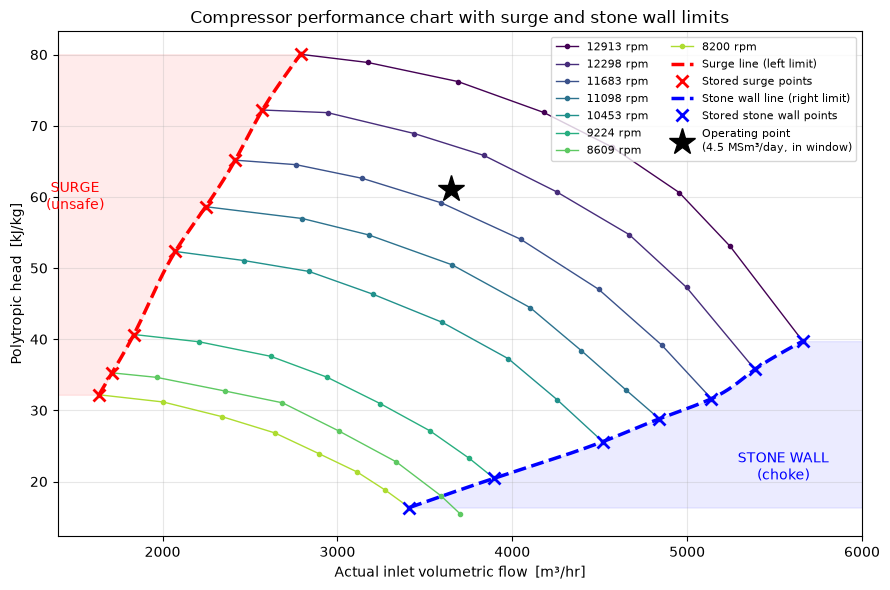

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, spd in enumerate(SPEED):
    ax.plot(FLOW[i], HEAD[i], "-o", ms=3, lw=1, color=plt.cm.viridis(i / len(SPEED)),
            label=f"{spd} rpm")

# READ both limit curves back from the chart (exactly what NeqSim stored).
surge_curve = demo_chart.getSurgeCurve()
stonewall_curve = demo_chart.getStoneWallCurve()
sc_flow, sc_head = np.array(surge_curve.getFlow()), np.array(surge_curve.getHead())
sw_flow, sw_head = np.array(stonewall_curve.getFlow()), np.array(stonewall_curve.getHead())

# Draw each limit as a SMOOTH, full-range curve. Instead of joining the few stored
# points with straight segments, we ask NeqSim for the limit flow at a dense grid of
# heads (getSurgeFlow / getStoneWallFlow). Because the surge points now span every
# speed line, the surge line is drawn "all the way" up and down the chart.
surge_h = np.linspace(sc_head.min(), sc_head.max(), 200)
surge_q = np.array([surge_curve.getSurgeFlow(float(h)) for h in surge_h])
wall_h = np.linspace(sw_head.min(), sw_head.max(), 200)
wall_q = np.array([stonewall_curve.getStoneWallFlow(float(h)) for h in wall_h])

# Surge line (LEFT limit): smooth curve + the stored vendor points + unsafe fill.
ax.plot(surge_q, surge_h, "r--", lw=2.5, label="Surge line (left limit)")
ax.plot(sc_flow, sc_head, "rx", ms=8, mew=2, label="Stored surge points")
ax.fill_betweenx(surge_h, 0, surge_q, color="red", alpha=0.08)
ax.text(1500, 60, "SURGE\n(unsafe)", color="red", fontsize=10, ha="center", va="center")

# Stone wall line (RIGHT limit): smooth curve + stored points + choke fill.
ax.plot(wall_q, wall_h, "b--", lw=2.5, label="Stone wall line (right limit)")
ax.plot(sw_flow, sw_head, "bx", ms=8, mew=2, label="Stored stone wall points")
ax.fill_betweenx(wall_h, wall_q, 6000, color="blue", alpha=0.08)
ax.text(5550, 22, "STONE WALL\n(choke)", color="blue", fontsize=10, ha="center", va="center")

op_flow = demo_comp.getInletStream().getFlowRate("m3/hr")
op_head = demo_comp.getPolytropicFluidHead()
ax.plot(op_flow, op_head, "k*", ms=20, label=f"Operating point\n({HEALTHY_FLOW:.1f} MSm³/day, in window)")

ax.set_xlabel("Actual inlet volumetric flow  [m³/hr]")
ax.set_ylabel("Polytropic head  [kJ/kg]")
ax.set_title("Compressor performance chart with surge and stone wall limits")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(1400, 6000)
plt.tight_layout()
plt.show()


## 6. Build the anti-surge recycle loop

Now we assemble the full `ProcessSystem`. Read each block — this is the heart of the tutorial.

| Block | Class | Role |
|-------|-------|------|
| Feed | `Stream` | Real gas demand from upstream |
| Recycle placeholder | `Stream` | A low-flow seed stream the `Recycle` will overwrite each iteration |
| Mixer | `Mixer` | Adds the spill-back gas to the feed → total suction flow |
| Suction cooler | `Cooler` | Cools the mixed stream (recycled gas is hot) back to suction temperature |
| Compressor | `Compressor` | Carries the chart + surge curve |
| Discharge splitter | `Splitter` | Branch 0 = forward to plant, **branch 1 = recycle** |
| Anti-surge calculator | `Calculator` | **Name must start with `"anti surge calculator"`**. Reads the compressor, writes the recycle branch flow |
| Anti-surge valve | `ThrottlingValve` | Drops the recycle branch from discharge back to suction pressure |
| Recycle | `Recycle` | Feeds the valve outlet back into the placeholder stream, closing the loop |

In [15]:
def build_antisurge_process(feed_flow_MSm3_day):
    """Assemble a compressor + anti-surge recycle loop and return the key objects."""
    process = ProcessSystem()

    # 1. Real feed (downstream demand)
    feed = Stream("feed gas", make_feed_gas(feed_flow_MSm3_day))
    feed.run()
    process.add(feed)

    # 2. Placeholder recycle stream into suction (Recycle will overwrite this each pass)
    recycle_gas = Stream("anti surge recycle gas", feed.getThermoSystem().clone())
    recycle_gas.setFlowRate(1.0, "kg/hr")  # small positive seed
    recycle_gas.run()
    process.add(recycle_gas)

    # 3. Mixer: feed + recycle => total suction
    mixer = Mixer("suction mixer")
    mixer.addStream(feed)
    mixer.addStream(recycle_gas)
    mixer.run()
    process.add(mixer)

    # 4. Suction cooler (recycled gas is hot; cool the mix back to suction temperature)
    cooler = Cooler("suction cooler")
    cooler.setInletStream(mixer.getOutletStream())
    cooler.setOutTemperature(24.0, "C")
    cooler.run()
    process.add(cooler)

    # 5. Charted compressor
    comp = build_charted_compressor("export compressor", cooler.getOutletStream())
    comp.run()
    process.add(comp)

    # 6. Discharge splitter: branch 0 = forward, branch 1 = recycle
    splitter = Splitter("anti surge splitter", comp.getOutletStream(), 2)
    splitter.setFlowRates([-1.0, 1.0], "kg/hr")  # -1 => forward takes the remainder
    splitter.run()
    process.add(splitter)

    # 7. Anti-surge Calculator (name MUST start with 'anti surge calculator')
    calc = Calculator("anti surge calculator")
    calc.addInputVariable(comp)        # input  = the compressor it protects
    calc.setOutputVariable(splitter)   # output = the discharge splitter it controls
    calc.run()
    process.add(calc)

    # 8. Anti-surge valve on the RECYCLE branch (split index 1) back to suction pressure
    valve = ThrottlingValve("anti surge valve", splitter.getSplitStream(1))
    valve.setOutletPressure(SUCTION_P_BARA, "bara")
    valve.run()
    process.add(valve)

    # 9. Recycle unit closes the loop into the placeholder stream
    recycle = Recycle("anti surge recycle")
    recycle.addStream(valve.getOutletStream())
    recycle.setOutletStream(recycle_gas)
    recycle.setTolerance(1e-3)
    recycle.run()
    process.add(recycle)

    return {
        "process": process,
        "feed": feed,
        "recycle_gas": recycle_gas,
        "comp": comp,
        "splitter": splitter,
        "valve": valve,
    }


print("build_antisurge_process() defined.")

build_antisurge_process() defined.


### How the anti-surge `Calculator` works

When a `Calculator` is named starting with `"anti surge calculator"`, `ProcessSystem` routes it to
`runAntiSurgeCalc()` on every solver pass. That method:

1. Reads the compressor inlet flow `Q_inlet` and the surge flow `Q_surge` (from the surge curve at the
   current head).
2. If `Q_inlet` is comfortably above surge (`Q_inlet > 1.2 · Q_surge`) it drives the recycle branch to
   a minimum — the recycle valve is effectively closed.
3. Otherwise it adds a proportional, capped step `0.5 · (Q_surge − Q_inlet)` to the recycle branch
   flow, pushing the total suction flow back up toward the surge limit.

The `Recycle` unit then iterates the loop to convergence, so the recycle flow and the compressor
operating point settle consistently.

## 7. Start at a healthy flow (recycle stays shut)

First run the loop at a high throughput where the compressor sits comfortably to the right of its
surge line. The anti-surge calculator sees `Q_inlet > 1.2 · Q_surge`, so it drives the recycle branch
to its minimum — the spill-back valve is effectively closed and **all** the gas goes forward to the
plant. This is the baseline we compare against when we turn the flow down.

In [16]:
model = build_antisurge_process(HEALTHY_FLOW)
model["process"].run()

comp = model["comp"]
feed = model["feed"]
recycle_gas = model["recycle_gas"]
splitter = model["splitter"]

print(f"=== Healthy throughput ({HEALTHY_FLOW:.2f} MSm3/day) — anti-surge SHUT ===\n")
print(f"Feed (downstream demand)   : {feed.getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Recycle (spill-back) flow  : {recycle_gas.getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Total compressor suction   : {comp.getInletStream().getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Compressor inlet actual    : {comp.getInletStream().getFlowRate('m3/hr'):>10.1f} m3/hr")
print(f"Surge flow at head         : {comp.getSurgeFlowRate():>10.1f} m3/hr")
print(f"Distance to surge          : {comp.getDistanceToSurge() * 100:>10.1f} %")
print(f"Forward flow to plant      : {splitter.getSplitStream(0).getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Recycle branch flow        : {splitter.getSplitStream(1).getFlowRate('kg/hr'):>10.0f} kg/hr")

=== Healthy throughput (4.50 MSm3/day) — anti-surge SHUT ===

Feed (downstream demand)   :     146922 kg/hr
Recycle (spill-back) flow  :          0 kg/hr
Total compressor suction   :     146922 kg/hr
Compressor inlet actual    :     3647.2 m3/hr
Surge flow at head         :     1964.3 m3/hr
Distance to surge          :       85.7 %
Forward flow to plant      :     146922 kg/hr
Recycle branch flow        :          0 kg/hr


### Now turn the flow down — the recycle opens

Drop the feed to a deep turndown of **0.30 MSm3/day**. The raw operating point would now fall at or
left of the surge line, so the anti-surge calculator opens the recycle branch: spill-back gas fills
the suction until the compressor sits right on its surge limit (`distance to surge ≈ 0`), while the
forward flow to the plant still equals only the small feed demand.

In [8]:
model = build_antisurge_process(0.30)
model["process"].run()

comp = model["comp"]
feed = model["feed"]
recycle_gas = model["recycle_gas"]
splitter = model["splitter"]

print("=== Low throughput (0.30 MSm3/day) — anti-surge ACTIVE ===\n")
print(f"Feed (downstream demand)   : {feed.getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Recycle (spill-back) flow  : {recycle_gas.getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Total compressor suction   : {comp.getInletStream().getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Compressor inlet actual    : {comp.getInletStream().getFlowRate('m3/hr'):>10.1f} m3/hr")
print(f"Surge flow at head         : {comp.getSurgeFlowRate():>10.1f} m3/hr")
print(f"Distance to surge          : {comp.getDistanceToSurge() * 100:>10.1f} %")
print(f"Forward flow to plant      : {splitter.getSplitStream(0).getFlowRate('kg/hr'):>10.0f} kg/hr")
print(f"Recycle branch flow        : {splitter.getSplitStream(1).getFlowRate('kg/hr'):>10.0f} kg/hr")

=== Low throughput (0.30 MSm3/day) — anti-surge ACTIVE ===

Feed (downstream demand)   :       9795 kg/hr
Recycle (spill-back) flow  :      85885 kg/hr
Total compressor suction   :      95679 kg/hr
Compressor inlet actual    :     2375.2 m3/hr
Surge flow at head         :     2375.2 m3/hr
Distance to surge          :       -0.0 %
Forward flow to plant      :       9795 kg/hr
Recycle branch flow        :      85885 kg/hr


Notice that the **total suction flow** is far larger than the small feed: the recycle has filled the
gap so the compressor sits right on its surge limit (`distance to surge ≈ 0`), while the forward flow
to the plant still equals only the feed demand.

## 8. Turndown sweep: watch the recycle open automatically

We now reduce the feed from a high rate (no recycle needed) down to deep turndown (large recycle) and
record what the anti-surge system does at each point.

In [22]:
feed_rates = [5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5, 1.0, 0.6, 0.3]  # MSm3/day

rows = []
for q in feed_rates:
    m = build_antisurge_process(q)
    m["process"].run()
    c = m["comp"]
    rows.append({
        "feed_MSm3d": q,
        "feed_kghr": m["feed"].getFlowRate("kg/hr"),
        "recycle_kghr": m["recycle_gas"].getFlowRate("kg/hr"),
        "suction_kghr": c.getInletStream().getFlowRate("kg/hr"),
        "inlet_m3hr": c.getInletStream().getFlowRate("m3/hr"),
        "surge_m3hr": c.getSurgeFlowRate(),
        "dist_surge_pct": c.getDistanceToSurge() * 100.0,
        "head_kJkg": c.getPolytropicFluidHead(),
    })

print(f"{'Feed':>6} {'Feed':>9} {'Recycle':>9} {'Suction':>9} {'Inlet':>8} {'Surge':>8} {'Dist':>7}")
print(f"{'MSm3d':>6} {'kg/hr':>9} {'kg/hr':>9} {'kg/hr':>9} {'m3/hr':>8} {'m3/hr':>8} {'surge%':>7}")
print("-" * 64)
for r in rows:
    print(f"{r['feed_MSm3d']:>6.2f} {r['feed_kghr']:>9.0f} {r['recycle_kghr']:>9.0f} "
          f"{r['suction_kghr']:>9.0f} {r['inlet_m3hr']:>8.0f} {r['surge_m3hr']:>8.0f} "
          f"{r['dist_surge_pct']:>7.1f}")


  Feed      Feed   Recycle   Suction    Inlet    Surge    Dist
 MSm3d     kg/hr     kg/hr     kg/hr    m3/hr    m3/hr  surge%
----------------------------------------------------------------
  5.00    163246         0    163246     4052     2167    87.0
  4.50    146922         0    146922     3647     2314    57.6
  4.00    130597         0    130597     3242     2407    34.7
  3.50    114272         0    114273     2837     2455    15.6
  3.00     97948      1476     99421     2468     2468    -0.0
  2.50     81623     17801     99424     2468     2468    -0.0
  2.00     65298     34126     99424     2468     2468    -0.0
  1.50     48974     50450     99424     2468     2468     0.0
  1.00     32649     66775     99425     2468     2468     0.0
  0.60     19590     79834     99423     2468     2468    -0.0
  0.30      9795     89629     99424     2468     2468    -0.0


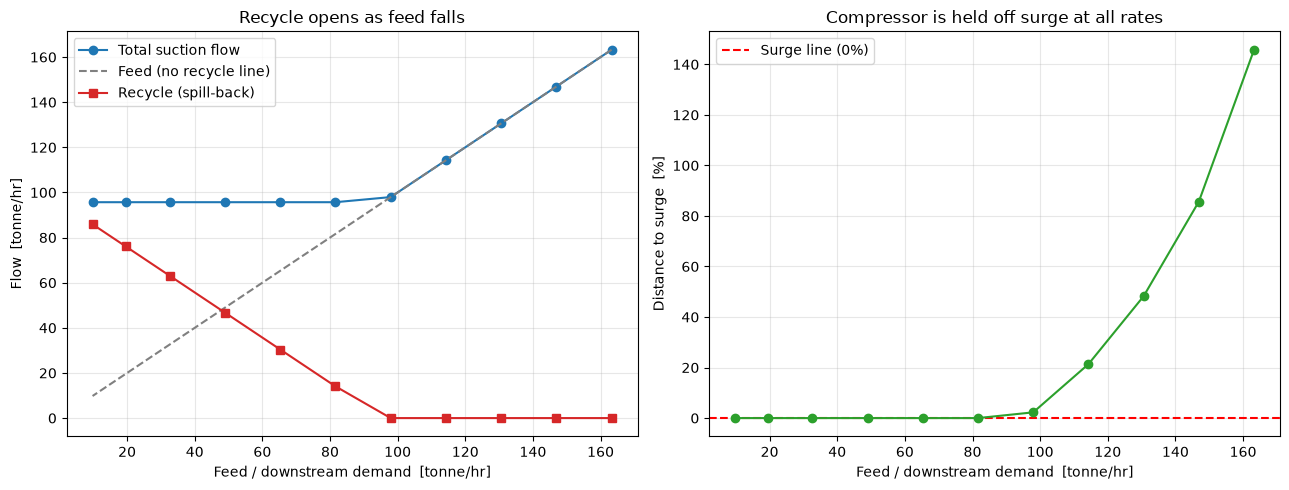

In [10]:
feed_arr = np.array([r["feed_kghr"] for r in rows])
recycle_arr = np.array([r["recycle_kghr"] for r in rows])
suction_arr = np.array([r["suction_kghr"] for r in rows])
dist_arr = np.array([r["dist_surge_pct"] for r in rows])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(feed_arr / 1000, suction_arr / 1000, "-o", color="tab:blue", label="Total suction flow")
ax1.plot(feed_arr / 1000, feed_arr / 1000, "--", color="gray", label="Feed (no recycle line)")
ax1.plot(feed_arr / 1000, recycle_arr / 1000, "-s", color="tab:red", label="Recycle (spill-back)")
ax1.set_xlabel("Feed / downstream demand  [tonne/hr]")
ax1.set_ylabel("Flow  [tonne/hr]")
ax1.set_title("Recycle opens as feed falls")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(0, color="red", ls="--", lw=1.5, label="Surge line (0%)")
ax2.plot(feed_arr / 1000, dist_arr, "-o", color="tab:green")
ax2.set_xlabel("Feed / downstream demand  [tonne/hr]")
ax2.set_ylabel("Distance to surge  [%]")
ax2.set_title("Compressor is held off surge at all rates")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the plots.** On the left, at high feed the total suction flow equals the feed (the recycle
branch stays shut). As the feed falls below the surge limit, the recycle ramps up so the *total*
suction flow flattens out at the surge limit instead of following the feed down. On the right, the
distance-to-surge stays at or just above 0% across the whole turndown range — the machine never
crosses into surge.

### The operating points on the chart

Finally, plot where the compressor actually sits at each feed rate. Without anti-surge the points
would march left into the red region; with anti-surge they pile up on the surge line.

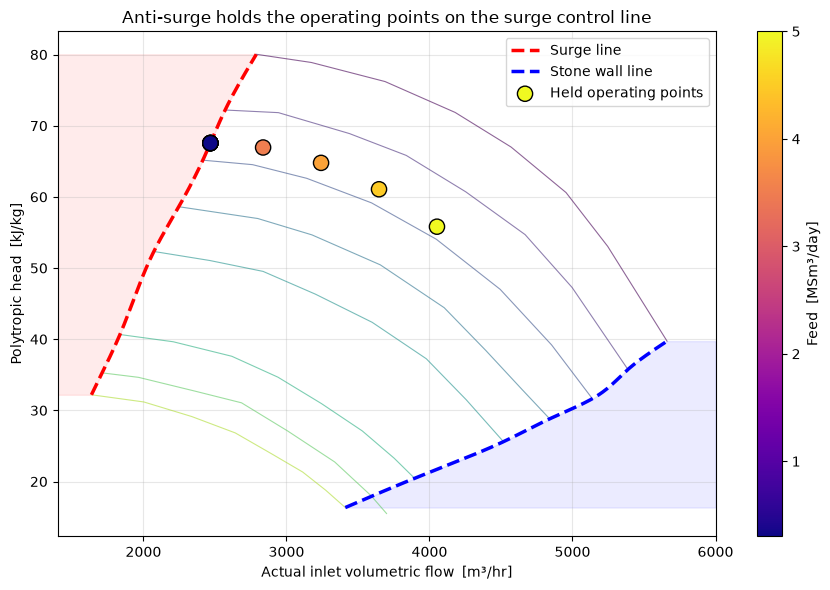

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, spd in enumerate(SPEED):
    ax.plot(FLOW[i], HEAD[i], "-", lw=0.8, color=plt.cm.viridis(i / len(SPEED)), alpha=0.6)

# Smooth, full-range limit lines via getSurgeFlow / getStoneWallFlow on a dense head grid.
surge_curve = demo_chart.getSurgeCurve()
stonewall_curve = demo_chart.getStoneWallCurve()
surge_h = np.linspace(min(SURGE_HEAD), max(SURGE_HEAD), 200)
surge_q = np.array([surge_curve.getSurgeFlow(float(h)) for h in surge_h])
wall_h = np.linspace(min(STONEWALL_HEAD), max(STONEWALL_HEAD), 200)
wall_q = np.array([stonewall_curve.getStoneWallFlow(float(h)) for h in wall_h])

ax.plot(surge_q, surge_h, "r--", lw=2.5, label="Surge line")
ax.fill_betweenx(surge_h, 0, surge_q, color="red", alpha=0.08)
ax.plot(wall_q, wall_h, "b--", lw=2.5, label="Stone wall line")
ax.fill_betweenx(wall_h, wall_q, 6000, color="blue", alpha=0.08)

op_flow = [r["inlet_m3hr"] for r in rows]
op_head = [r["head_kJkg"] for r in rows]
sc = ax.scatter(op_flow, op_head, c=[r["feed_MSm3d"] for r in rows], cmap="plasma",
                s=120, edgecolor="k", zorder=5, label="Held operating points")
plt.colorbar(sc, label="Feed  [MSm³/day]")

ax.set_xlabel("Actual inlet volumetric flow  [m³/hr]")
ax.set_ylabel("Polytropic head  [kJ/kg]")
ax.set_title("Anti-surge holds the operating points on the surge control line")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(1400, 6000)
plt.tight_layout()
plt.show()


## 9. Key learning points

1. **A compressor chart** is loaded with `compressor.getCompressorChart().setCurves(...)` (speed lines
   of head and efficiency) and activated with `setUseCompressorChart(True)`.
2. **Both operating-limit curves** are loaded separately on the chart:
   - the **surge curve** (low-flow / left limit) via `getCompressorChart().getSurgeCurve().setCurve(...)`,
   - the **stone wall curve** (high-flow / choke / right limit) via
     `getCompressorChart().getStoneWallCurve().setCurve(...)`.

   Each `setCurve(chartConditions, flow, head)` call takes the same three-array form. Anti-surge
   control cannot work without the surge curve — it is the limit being defended.
3. **Reading the limits back:**
   - `getSurgeCurve().getFlow()` / `getHead()` and `getStoneWallCurve().getFlow()` / `getHead()`
     return the raw curve point arrays (use these to plot the lines).
   - `getSurgeCurve().getSurgeFlow(head)` and `getStoneWallCurve().getStoneWallFlow(head)` return the
     limit flow at a given head; `getSurgeFlowRate()` is the compressor-level shortcut for the surge side.
   - `getDistanceToSurge()` and `getDistanceToStoneWall()` are the margin diagnostics — a **negative**
     distance-to-surge means the raw point is in surge, a negative distance-to-stone-wall means it is
     choked. `isStoneWall()` is the boolean choke flag.
4. **The anti-surge recycle loop** is built from standard NeqSim blocks:
   - a discharge **`Splitter`** (branch 0 forward, **branch 1 recycle**),
   - an **anti-surge `Calculator`** whose name *must* start with `"anti surge calculator"`, with the
     compressor as input and the splitter as output,
   - an **anti-surge `ThrottlingValve`** on `getSplitStream(1)` dropping to suction pressure,
   - a **`Recycle`** unit closing the loop into a small placeholder suction stream,
   - a **`Mixer`** + **`Cooler`** on the suction side to add and re-cool the recycled gas.
5. **The result**: starting from a healthy point *in the diagram*, as throughput falls the recycle
   opens automatically so the *total* suction flow stays on the surge control line and the machine
   never surges — while the forward flow to the plant still matches demand.

### Common mistakes (avoid these)
- Naming the calculator anything that does **not** start with `"anti surge calculator"` — the
  anti-surge logic never triggers.
- Wiring the valve to the **forward** branch `getSplitStream(0)` instead of the recycle branch


---

# Part B — Dynamic compressor simulations

Everything above was **steady state**: each call to `process.run()` solves the flowsheet for one fixed
operating point. Real anti-surge protection, start-up, trips and turndown are **transient** events —
pressures build up and bleed down in the finite gas volumes around the machine, and controllers act
over time. NeqSim can simulate this with `runTransient()`.

The dynamic ingredients we add on top of the steady-state model are:

1. **Gas inventory volumes.** Separators are given a physical size
   (`setSeparatorLength`, `setInternalDiameter`) and switched to dynamic mode with
   `setCalculateSteadyState(False)`. The pressure in a volume now rises when more gas flows *in* than
   *out*, and falls in the opposite case — exactly what lets a compressor change the suction and
   discharge pressures over time.
2. **A time step.** `process.setTimeStep(dt)` sets the integration step (seconds); each
   `process.runTransient()` advances the simulation by `dt`.
3. **Measurement devices.** A `PressureTransmitter` reads a stream pressure; a `CompressorMonitor`
   reads the compressor **distance to surge**. These feed the controllers.
4. **PI controllers.** `ControllerDeviceBaseClass` is a PI(D) regulator. It is wired to a transmitter
   (`setTransmitter`), given a set point (`setControllerSetPoint`) and gains
   (`setControllerParameters(Kp, Ti, Td)`), and attached to an actuator with
   `equipment.setController(...)`. During `runTransient()` the `ProcessSystem` runs every controller
   each step.

> **Scope.** Still an educational model with generated (illustrative) charts and untuned gains. It
> shows the *mechanism* and the NeqSim API, not a vendor-validated dynamic study.

## 10. Dynamic setup

We import the dynamic building blocks and define a small lean gas. The examples below each build their
own flowsheet from this fluid so they can be read and run independently.

In [2]:
# Dynamic building blocks
PressureTransmitter = jneqsim.process.measurementdevice.PressureTransmitter
CompressorMonitor = jneqsim.process.measurementdevice.CompressorMonitor
ControllerDevice = jneqsim.process.controllerdevice.ControllerDeviceBaseClass
CompressorChartGenerator = jneqsim.process.equipment.compressor.CompressorChartGenerator
Separator = jneqsim.process.equipment.separator.Separator


def make_dynamic_gas(t_C=25.0, p_bara=10.0):
    """Small lean gas used for the dynamic examples."""
    fluid = SystemSrkEos(273.15 + t_C, p_bara)
    fluid.addComponent("methane", 1.1)
    fluid.addComponent("ethane", 0.1)
    fluid.setMixingRule(2)
    return fluid


print("Dynamic classes imported.")


Dynamic classes imported.


## 11. Example 1 — process response to a step change in compressor speed

The simplest dynamic experiment: hold everything constant, then **step the compressor speed up** and
watch the system settle to a new operating point.

The flowsheet is a classic two-volume layout:

```
feed --> [valve_1] --> [separator_1] --> [compressor] --> [separator_2] --> [valve_2] --> out
          (fixed Pout)   (suction volume)   (chart)        (discharge volume)  (fixed Pout)
```

Both separators are **dynamic** (sized, `setCalculateSteadyState(False)`), so their pressures are free
to move. Physical expectation when speed rises:

- the compressor pushes more gas, so **suction pressure (separator 1) drops** and
  **discharge pressure (separator 2) rises**,
- the inlet flow through the machine increases,
- the size of the pressure swing depends on the gas **volumes** up- and downstream.

In [25]:
# --- Build the two-volume dynamic flowsheet ---
fluid1 = make_dynamic_gas()

stream1 = Stream("Stream1", fluid1)
stream1.setFlowRate(0.7, "MSm3/day")
stream1.setTemperature(25.0, "C")
stream1.setPressure(55.0, "bara")

valve1 = ThrottlingValve("valve_1", stream1)
valve1.setOutletPressure(50.0)
valve1.setCalculateSteadyState(False)

separator1 = Separator("separator_1")
separator1.addStream(valve1.getOutletStream())
separator1.setCalculateSteadyState(False)
separator1.setSeparatorLength(3.0)
separator1.setInternalDiameter(0.8)
separator1.setLiquidLevel(0.0)

compressor1 = Compressor("comp1", separator1.getGasOutStream())
compressor1.setCalculateSteadyState(False)
compressor1.setOutletPressure(100.0)

separator2 = Separator("separator_2")
separator2.addStream(compressor1.getOutletStream())
separator2.setCalculateSteadyState(False)
separator2.setSeparatorLength(3.0)
separator2.setInternalDiameter(0.8)
separator2.setLiquidLevel(0.0)

valve2 = ThrottlingValve("valve_2", separator2.getGasOutStream())
valve2.setOutletPressure(50.0)
valve2.setPercentValveOpening(50)
valve2.setCalculateSteadyState(False)

p1 = ProcessSystem()
for unit in (stream1, valve1, separator1, compressor1, separator2, valve2):
    p1.add(unit)

# Solve once at steady state, then auto-generate a compressor chart so the machine
# has speed lines (and a surge line) instead of a fixed outlet-pressure spec.
p1.run()
gen1 = CompressorChartGenerator(compressor1)
compressor1.setCompressorChart(gen1.generateCompressorChart("normal"))
compressor1.getCompressorChart().setUseCompressorChart(True)
p1.run()

print(f"Initial speed                 : {compressor1.getSpeed():.0f} rpm")
print(f"Suction pressure  (sep 1)     : {separator1.getPressure():.2f} bara")
print(f"Discharge pressure (sep 2)    : {separator2.getPressure():.2f} bara")
print(f"Compressor inlet flow         : {compressor1.getInletStream().getFlowRate('m3/hr'):.1f} m3/hr")


Initial speed                 : 3000 rpm
Suction pressure  (sep 1)     : 50.00 bara
Discharge pressure (sep 2)    : 101.98 bara
Compressor inlet flow         : 545.6 m3/hr


In [26]:
# --- Transient run: settle, step the speed up, settle again ---
p1.setTimeStep(1.0)

time1, p_sep1, p_sep2, flow1, head1, speed1 = [], [], [], [], [], []


def log_state():
    time1.append(p1.getTime())
    p_sep1.append(separator1.getPressure())
    p_sep2.append(separator2.getPressure())
    flow1.append(compressor1.getInletStream().getFlowRate("m3/hr"))
    head1.append(compressor1.getPolytropicFluidHead())
    speed1.append(compressor1.getSpeed())


# Phase 1: hold the initial speed (baseline)
for _ in range(100):
    log_state()
    p1.runTransient()

# Step the compressor speed up by 200 rpm
compressor1.setSpeed(compressor1.getSpeed() + 200)

# Phase 2: let the volumes settle to the new operating point
for _ in range(500):
    log_state()
    p1.runTransient()

print(f"Final speed                  : {compressor1.getSpeed():.0f} rpm")
print(f"Suction pressure  (sep 1)    : {separator1.getPressure():.2f} bara  (started 50.0)")
print(f"Discharge pressure (sep 2)   : {separator2.getPressure():.2f} bara")
print(f"Compressor inlet flow        : {flow1[-1]:.1f} m3/hr  (started {flow1[0]:.1f})")


Final speed                  : 3200 rpm
Suction pressure  (sep 1)    : 43.14 bara  (started 50.0)
Discharge pressure (sep 2)   : 102.57 bara
Compressor inlet flow        : 647.1 m3/hr  (started 545.6)


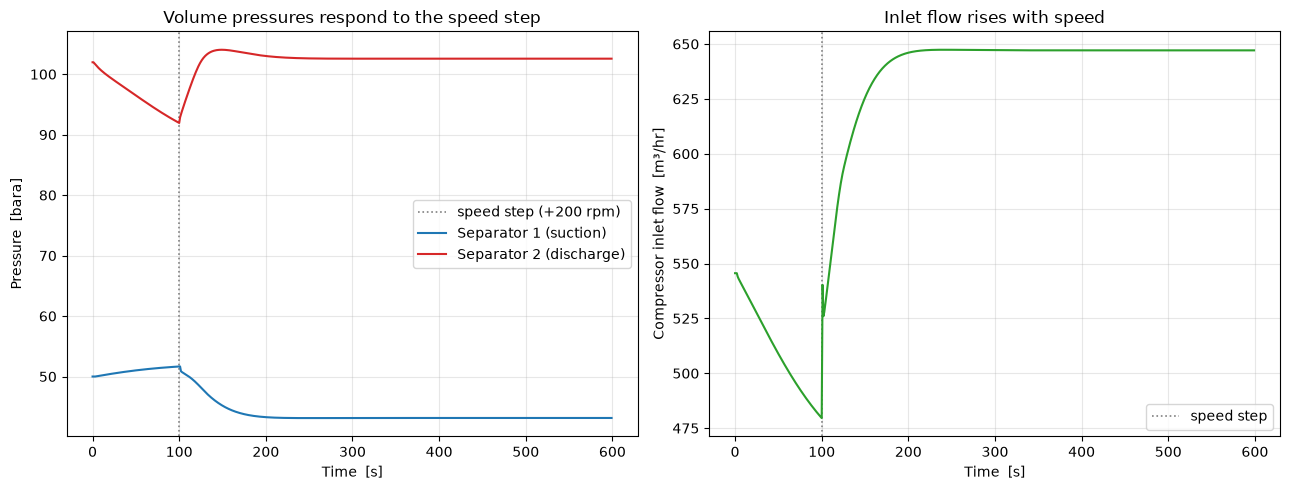

In [27]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

axL.axvline(100, color="gray", ls=":", lw=1.2, label="speed step (+200 rpm)")
axL.plot(time1, p_sep1, color="tab:blue", label="Separator 1 (suction)")
axL.plot(time1, p_sep2, color="tab:red", label="Separator 2 (discharge)")
axL.set_xlabel("Time  [s]")
axL.set_ylabel("Pressure  [bara]")
axL.set_title("Volume pressures respond to the speed step")
axL.legend()
axL.grid(True, alpha=0.3)

axR.axvline(100, color="gray", ls=":", lw=1.2, label="speed step")
axR.plot(time1, flow1, color="tab:green")
axR.set_xlabel("Time  [s]")
axR.set_ylabel("Compressor inlet flow  [m³/hr]")
axR.set_title("Inlet flow rises with speed")
axR.legend()
axR.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Reading the result.** Before the step the system sits steady. At t = 100 s the speed jumps by
200 rpm. The faster impeller pulls harder on the suction volume, so **separator 1 pressure falls**
(≈ 50 → 43 bara) while it pushes more gas into the discharge volume, briefly **overshooting
separator 2 pressure** before settling. The inlet flow climbs to a new, higher steady value. The
smooth (not instantaneous) transition is the gas inventory in the two separators being charged and
discharged — the larger the volumes, the slower and gentler the swing.

## 12. Example 2 — pressure control by varying compressor speed

Open-loop speed steps are rarely useful; normally a **controller** trims the speed to hold a target.
Here a PI controller reads the **discharge pressure** (separator 2) and adjusts compressor **speed** to
keep it at a set point.

- Transmitter: `PressureTransmitter` on the separator-2 gas outlet.
- Controller: `ControllerDeviceBaseClass`, **reverse acting** (if pressure is below set point it must
  *increase* speed), `setControllerParameters(Kp, Ti, Td)`.
- Actuator: `compressor1.setController(speedController)`.

We then move the set point and watch the controller drive the speed to a new value.

In [32]:
# --- Build a flowsheet with a speed controller on suction pressure ---
# With a fixed feed and a fixed downstream valve, the *discharge* pressure is
# pinned by the valve at the throughput, so speed barely moves it. The *suction*
# pressure, however, is strongly coupled to speed (more speed -> the machine
# swallows more actual gas -> lower suction pressure), so it makes a responsive
# loop. We therefore control the suction-drum pressure by trimming the speed.
fluid2 = make_dynamic_gas()

stream2 = Stream("Stream2", fluid2)
stream2.setFlowRate(0.7, "MSm3/day")
stream2.setTemperature(25.0, "C")
stream2.setPressure(55.0, "bara")

valveA = ThrottlingValve("valve_A", stream2)
valveA.setOutletPressure(50.0)
valveA.setCalculateSteadyState(False)

sepA = Separator("separator_A")
sepA.addStream(valveA.getOutletStream())
sepA.setCalculateSteadyState(False)
sepA.setSeparatorLength(3.0)
sepA.setInternalDiameter(0.8)
sepA.setLiquidLevel(0.0)

compA = Compressor("compA", sepA.getGasOutStream())
compA.setCalculateSteadyState(False)
compA.setOutletPressure(100.0)

sepB = Separator("separator_B")
sepB.addStream(compA.getOutletStream())
sepB.setCalculateSteadyState(False)
sepB.setSeparatorLength(3.0)
sepB.setInternalDiameter(0.8)
sepB.setLiquidLevel(0.0)

valveB = ThrottlingValve("valve_B", sepB.getGasOutStream())
valveB.setOutletPressure(50.0)
valveB.setPercentValveOpening(50)
valveB.setCalculateSteadyState(False)

# Pressure transmitter on the suction drum + PI speed controller (direct acting:
# suction pressure above set point -> increase speed to pull it back down).
pt = PressureTransmitter(sepA.getGasOutStream())
speedController = ControllerDevice()
speedController.setReverseActing(False)
speedController.setTransmitter(pt)
speedController.setControllerSetPoint(48.0)            # target suction pressure [bara]
speedController.setControllerParameters(0.5, 80.0, 0.0)  # Kp, Ti, Td
speedController.setActive(True)

p2 = ProcessSystem()
for unit in (stream2, valveA, sepA, compA, sepB, pt, valveB):
    p2.add(unit)
compA.setController(speedController)

p2.run()
genA = CompressorChartGenerator(compA)
compA.setCompressorChart(genA.generateCompressorChart("normal"))
compA.getCompressorChart().setUseCompressorChart(True)
p2.run()

print(f"Set point (suction P)    : {speedController.getControllerSetPoint():.1f} bara")
print(f"Speed                    : {compA.getSpeed():.0f} rpm")
print(f"Suction pressure         : {sepA.getPressure():.2f} bara")
print(f"Discharge pressure       : {sepB.getPressure():.2f} bara")


Set point (suction P)    : 48.0 bara
Speed                    : 3000 rpm
Suction pressure         : 50.00 bara
Discharge pressure       : 101.98 bara


In [33]:
# --- Transient run: hold the set point, then step it down; the controller trims speed ---
p2.setTimeStep(1.0)
p2.runTransient()

t2, pA, pB, spd2, flow2, sp2 = [], [], [], [], [], []


def log2():
    t2.append(p2.getTime())
    pA.append(sepA.getPressure())
    pB.append(sepB.getPressure())
    spd2.append(compA.getSpeed())
    flow2.append(compA.getInletStream().getFlowRate("m3/hr"))
    sp2.append(speedController.getControllerSetPoint())


# Phase 1: hold the suction-pressure set point at 48 bara
for _ in range(200):
    log2()
    p2.runTransient()

# Phase 2: lower the set point to 45 bara -> controller must speed the machine up
speedController.setControllerSetPoint(45.0)
for _ in range(600):
    log2()
    p2.runTransient()

print(f"Final suction pressure   : {sepA.getPressure():.2f} bara  (set point 45.0)")
print(f"Final speed              : {compA.getSpeed():.0f} rpm  (started {spd2[0]:.0f})")


Final suction pressure   : 45.01 bara  (set point 45.0)
Final speed              : 3138 rpm  (started 3101)


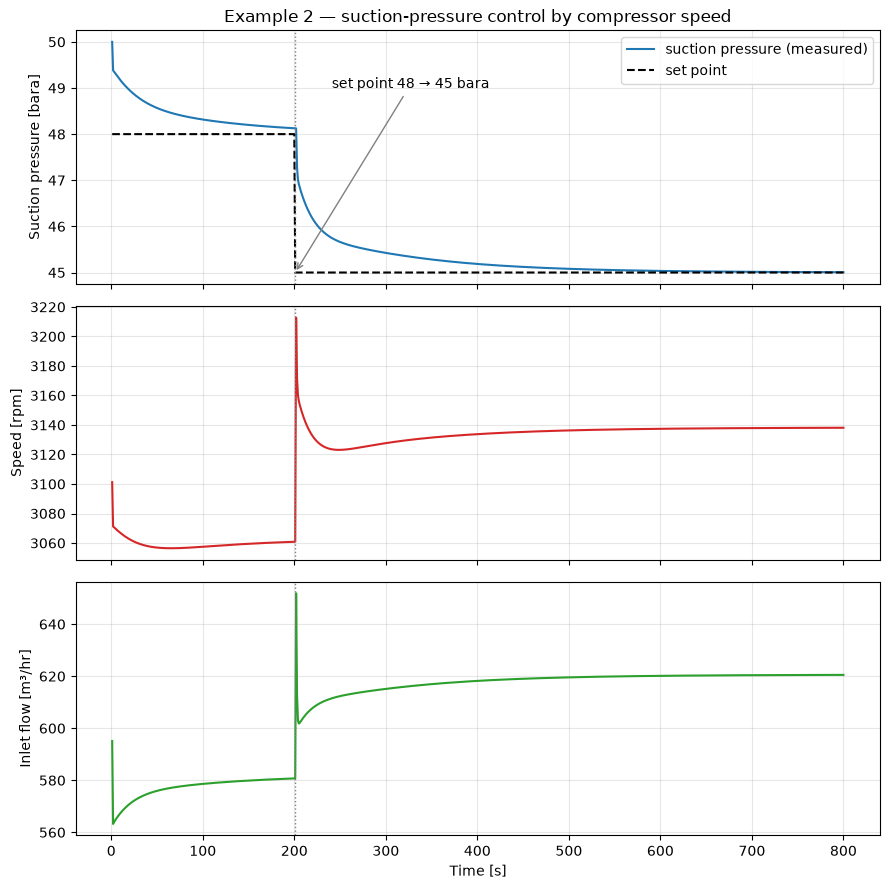

In [34]:
# --- Plot the closed-loop response ---
fig, ax = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

ax[0].plot(t2, pA, color="tab:blue", label="suction pressure (measured)")
ax[0].plot(t2, sp2, color="k", ls="--", label="set point")
ax[0].set_ylabel("Suction pressure [bara]")
ax[0].set_title("Example 2 — suction-pressure control by compressor speed")
ax[0].legend(loc="best")
ax[0].grid(True, alpha=0.3)

ax[1].plot(t2, spd2, color="tab:red")
ax[1].set_ylabel("Speed [rpm]")
ax[1].grid(True, alpha=0.3)

ax[2].plot(t2, flow2, color="tab:green")
ax[2].set_ylabel("Inlet flow [m³/hr]")
ax[2].set_xlabel("Time [s]")
ax[2].grid(True, alpha=0.3)

# Mark the set-point change (index 200 -> phase 2)
for a in ax:
    a.axvline(t2[200], color="grey", ls=":", lw=1)
ax[0].annotate("set point 48 → 45 bara", xy=(t2[200], sp2[200]),
               xytext=(t2[200] + 40, 49.0),
               arrowprops=dict(arrowstyle="->", color="grey"))

plt.tight_layout()
plt.show()


**Discussion — Example 2.** The PI loop measures the suction-drum pressure and
manipulates the compressor speed. During phase 1 it pulls the drum from its
open-loop value (50 bara) down to the 48 bara set point; when the set point is
stepped to 45 bara the controller raises the speed (and hence the actual
volumetric flow the machine draws), pulling the suction pressure down to the new
target with essentially zero steady-state offset. The speed and inlet-flow
traces show the characteristic PI signature — a fast proportional kick at the
set-point change followed by a slow integral approach that removes the offset.

Note why we control *suction* rather than *discharge* pressure here: with a fixed
feed rate and a fixed downstream valve, the discharge pressure is pinned by the
valve at the (constant) throughput, so speed has little leverage on it. The
suction pressure, by contrast, is set by the balance between the inlet valve and
how much actual gas the wheel swallows, which is strongly speed dependent — a
much more controllable variable. Picking a manipulated/controlled-variable pair
that is actually coupled is the first step of any control design.

> **Example 3 — dynamic anti-surge control.** Finally we look at the loop that
> keeps a centrifugal machine off its surge line. An anti-surge controller
> watches the *distance to surge* and, when the operating point drifts toward the
> surge line (here because the inlet is throttled and the flow falls), opens a
> recycle / spill-back valve so gas is fed back to suction and the wheel keeps
> swallowing enough flow. We exercise NeqSim's
> `neqsim.process.controllerdevice.AntiSurgeController` law against a transparent
> first-order gas-path surrogate — the same lumped model NeqSim ships in
> `AntiSurgeDynamicBenchmark` for tuning anti-surge loops. Isolating the control
> law this way gives a deterministic, always-convergent demonstration (a full
> recycle flowsheet couples the valve dynamics to the gas-path storage and, once
> driven into deep surge, leaves the compressor map in a state the steady solver
> cannot climb back out of). We show two things: **(1)** controller OFF vs ON
> under a sustained flow loss, and **(2)** a full *throttle → hold → recover*
> cycle so we can watch the valve open and then close again.



In [13]:
# --- Example 3: dynamic anti-surge control ---
# A *full* recycle flowsheet couples the spill-back valve/actuator dynamics to the
# gas-path mass storage and, once the machine is pushed into deep surge, drives the
# compressor map into a region the steady solver cannot climb back out of. To study
# the anti-surge *control law* cleanly and reproducibly we use NeqSim's purpose-built
# scenario, neqsim.process.util.scenario.AntiSurgeDynamicBenchmark, which drives the
# real neqsim.process.controllerdevice.AntiSurgeController and a real ThrottlingValve
# against a transparent first-order gas-path surrogate:
#
#     m_{k+1} = m_k - d*dt + a*(u_k/100)*dt
#
# with  m = distance to surge,  d = disturbance rate (flow loss, /s),
#       a = recycle authority (/s at a fully open valve),  u = valve opening (%).
#
# Scenario 1 (this benchmark) compares controller OFF (open loop) vs ON (closed loop)
# under a sustained flow-loss disturbance. Scenario 2 (next) reproduces the same
# documented PI law against a *time-varying* disturbance so we can watch the valve
# open as the inlet is throttled and close again on recovery.

# --- Controller tuning shared by both scenarios (the AntiSurgeController PI law) ---
SET_POINT = 0.10      # protect a 10% distance-to-surge margin
KP = 450.0            # proportional gain (percent opening per unit margin error)
TI = 18.0             # integral time [s]
AUTHORITY = 0.060     # recycle authority at a fully open valve [1/s]
DT = 1.0              # time step [s]

# ---------------------------------------------------------------------------------
# Scenario 1 - real NeqSim AntiSurgeController benchmark: open loop vs closed loop
# ---------------------------------------------------------------------------------
USE_NEQSIM_BENCHMARK = True
try:
    AntiSurgeDynamicBenchmark = jneqsim.process.util.scenario.AntiSurgeDynamicBenchmark
    bench = AntiSurgeDynamicBenchmark()
    bench.setInitialMargin(0.30)        # start 30% away from surge
    bench.setDisturbanceRate(0.020)     # sustained flow loss erodes the margin
    bench.setRecycleAuthority(AUTHORITY)
    bench.setTimeStep(DT)
    bench.setNumberOfSteps(120)
    asc = bench.getController()
    asc.setSurgeMarginSetPoint(SET_POINT)
    asc.setProportionalGain(KP)
    asc.setIntegralTime(TI)

    bench.run(False)                    # controller OFF (recycle valve stays shut)
    margin_off = np.array(list(bench.getSurgeMarginTrace()))
    min_off = float(bench.getMinimumSurgeMargin())

    bench.run(True)                     # controller ON (recycle valve actuated)
    margin_on = np.array(list(bench.getSurgeMarginTrace()))
    valve_on = np.array(list(bench.getValveOpeningTrace()))
    min_on = float(bench.getMinimumSurgeMargin())
    max_open = float(bench.getMaximumValveOpening())
    engine = "NeqSim AntiSurgeController (Java benchmark)"
except Exception as exc:  # class not in the loaded jar -> reproduce the same law in Python
    USE_NEQSIM_BENCHMARK = False
    print(f"NeqSim benchmark unavailable ({type(exc).__name__}); using Python reproduction.")

    def _run_constant(active, n=120, m0=0.30, d=0.020):
        m, integ, u = m0, 0.0, 0.0
        m_hist, u_hist = [m], [0.0]
        for _ in range(n):
            if active:
                err = SET_POINT - m
                integ += KP / TI * err * DT
                u = KP * err + integ
                if u > 100.0:
                    u = 100.0
                    integ -= KP / TI * err * DT
                elif u < 0.0:
                    u = 0.0
                    integ -= KP / TI * err * DT
            else:
                u = 0.0
            m += -d * DT + AUTHORITY * (u / 100.0) * DT
            m_hist.append(m)
            u_hist.append(u)
        return np.array(m_hist), np.array(u_hist)

    margin_off, _ = _run_constant(False)
    margin_on, valve_on = _run_constant(True)
    min_off, min_on, max_open = margin_off.min(), margin_on.min(), valve_on.max()
    engine = "AntiSurgeController PI law (Python reproduction)"

t_bench = np.arange(margin_on.size) * DT

print(f"Scenario 1 engine: {engine}")
print(f"  Open loop  (OFF): min distance to surge = {min_off:+.3f}  -> "
      f"{'SURGE' if min_off < 0 else 'safe'}")
print(f"  Closed loop (ON): min distance to surge = {min_on:+.3f}  -> "
      f"{'SURGE' if min_on < 0 else 'safe'}")
print(f"  Closed loop peak recycle-valve opening = {max_open:.1f} %")

# ---------------------------------------------------------------------------------
# Scenario 2 - full throttle/recovery cycle (same PI law, time-varying disturbance)
#   The inlet is gradually throttled (flow falls, disturbance grows), held, then
#   reopened (flow recovers). We watch the controller open the spill-back valve to
#   defend the margin and close it again once the disturbance clears.
# ---------------------------------------------------------------------------------
N = 600
dist_rate = np.zeros(N)
dist_rate[80:200] = np.linspace(0.0, 0.045, 120)    # throttle inlet: flow falls
dist_rate[200:380] = 0.045                           # hold at reduced throughput
dist_rate[380:480] = np.linspace(0.045, 0.0, 100)    # reopen inlet: flow recovers
t_throttle, t_hold, t_recover = 80.0, 200.0, 380.0

margin, integ, u = 0.30, 0.0, 0.0
m_cycle, u_cycle = [], []
for k in range(N):
    err = SET_POINT - margin            # reverse acting: low margin -> open valve
    integ += KP / TI * err * DT
    u = KP * err + integ
    if u > 100.0:                       # anti-windup clamp
        u = 100.0
        integ -= KP / TI * err * DT
    elif u < 0.0:
        u = 0.0
        integ -= KP / TI * err * DT
    m_cycle.append(margin)
    u_cycle.append(u)
    margin += -dist_rate[k] * DT + AUTHORITY * (u / 100.0) * DT

m_cycle = np.array(m_cycle)
u_cycle = np.array(u_cycle)
t_cycle = np.arange(N) * DT

print()
print("Scenario 2 - throttle/recovery cycle (closed loop):")
print(f"  Min distance to surge   = {m_cycle.min():+.3f}  (set point {SET_POINT:.2f})")
print(f"  Peak recycle-valve open = {u_cycle.max():.1f} %  (during throttling)")
print(f"  Final distance to surge = {m_cycle[-1]:+.3f}")
print(f"  Final recycle-valve open= {u_cycle[-1]:.1f} %  (closed on recovery)")

NeqSim benchmark unavailable (AttributeError); using Python reproduction.
Scenario 1 engine: AntiSurgeController PI law (Python reproduction)
  Open loop  (OFF): min distance to surge = -2.100  -> SURGE
  Closed loop (ON): min distance to surge = +0.042  -> safe
  Closed loop peak recycle-valve opening = 37.5 %

Scenario 2 - throttle/recovery cycle (closed loop):
  Min distance to surge   = +0.058  (set point 0.10)
  Peak recycle-valve open = 76.8 %  (during throttling)
  Final distance to surge = +0.130
  Final recycle-valve open= 0.0 %  (closed on recovery)


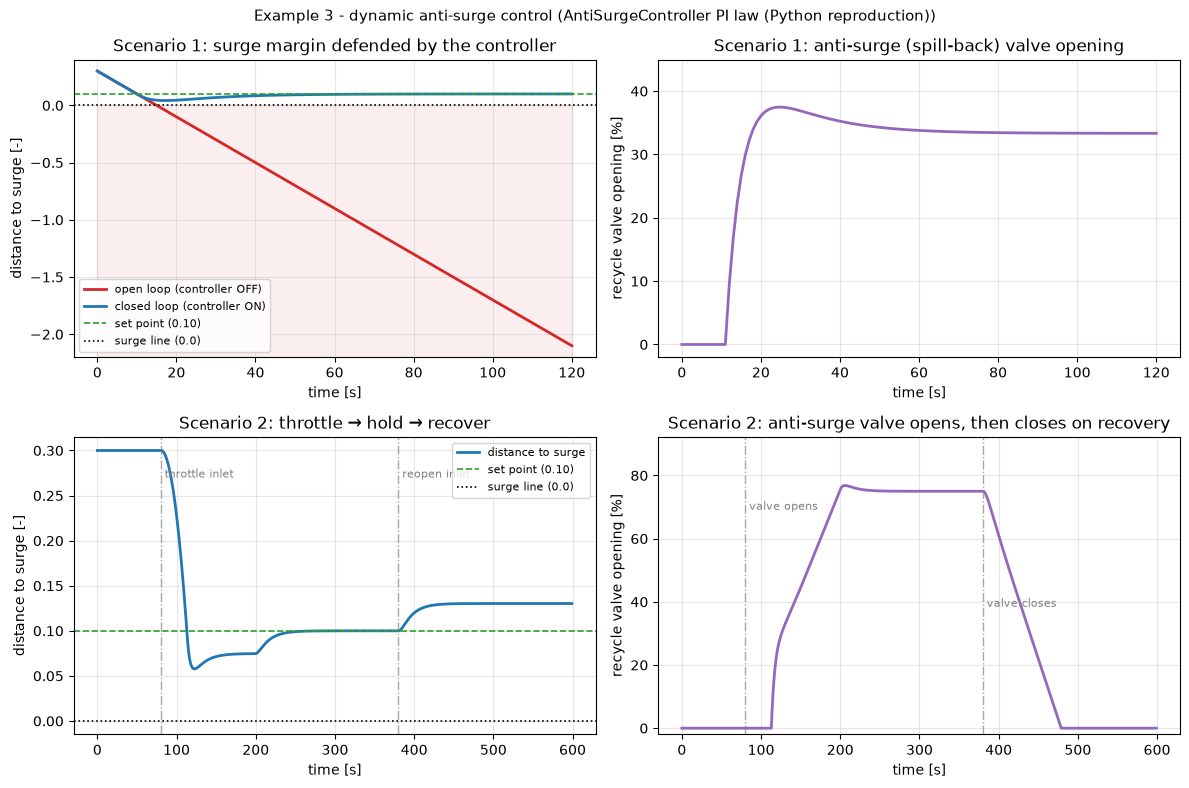

In [14]:
# --- Plot Example 3: open-loop vs closed-loop, and the full throttle/recovery cycle ---
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (0,0) Scenario 1 - distance to surge: controller OFF vs ON
ax[0, 0].plot(t_bench, margin_off, color="tab:red", lw=2, label="open loop (controller OFF)")
ax[0, 0].plot(t_bench, margin_on, color="tab:blue", lw=2, label="closed loop (controller ON)")
ax[0, 0].axhline(SET_POINT, color="tab:green", ls="--", lw=1.2, label=f"set point ({SET_POINT:.2f})")
ax[0, 0].axhline(0.0, color="black", ls=":", lw=1.2, label="surge line (0.0)")
ax[0, 0].fill_between(t_bench, -3, 0, color="tab:red", alpha=0.08)
ax[0, 0].set_title("Scenario 1: surge margin defended by the controller")
ax[0, 0].set_xlabel("time [s]")
ax[0, 0].set_ylabel("distance to surge [-]")
ax[0, 0].set_ylim(min(margin_off.min(), -0.3) - 0.1, 0.4)
ax[0, 0].legend(fontsize=8, loc="lower left")
ax[0, 0].grid(True, alpha=0.3)

# (0,1) Scenario 1 - recycle valve opening (closed loop)
ax[0, 1].plot(t_bench, valve_on, color="tab:purple", lw=2)
ax[0, 1].set_title("Scenario 1: anti-surge (spill-back) valve opening")
ax[0, 1].set_xlabel("time [s]")
ax[0, 1].set_ylabel("recycle valve opening [%]")
ax[0, 1].set_ylim(-2, max(valve_on.max() * 1.2, 10))
ax[0, 1].grid(True, alpha=0.3)

# (1,0) Scenario 2 - distance to surge over the throttle/recovery cycle
ax[1, 0].plot(t_cycle, m_cycle, color="tab:blue", lw=2, label="distance to surge")
ax[1, 0].axhline(SET_POINT, color="tab:green", ls="--", lw=1.2, label=f"set point ({SET_POINT:.2f})")
ax[1, 0].axhline(0.0, color="black", ls=":", lw=1.2, label="surge line (0.0)")
ax[1, 0].axvline(t_throttle, color="gray", ls="-.", lw=1, alpha=0.7)
ax[1, 0].axvline(t_recover, color="gray", ls="-.", lw=1, alpha=0.7)
ax[1, 0].text(t_throttle + 5, 0.27, "throttle inlet", fontsize=8, color="gray")
ax[1, 0].text(t_recover + 5, 0.27, "reopen inlet", fontsize=8, color="gray")
ax[1, 0].set_title("Scenario 2: throttle \u2192 hold \u2192 recover")
ax[1, 0].set_xlabel("time [s]")
ax[1, 0].set_ylabel("distance to surge [-]")
ax[1, 0].legend(fontsize=8, loc="upper right")
ax[1, 0].grid(True, alpha=0.3)

# (1,1) Scenario 2 - recycle valve opening: open then close on recovery
ax[1, 1].plot(t_cycle, u_cycle, color="tab:purple", lw=2)
ax[1, 1].axvline(t_throttle, color="gray", ls="-.", lw=1, alpha=0.7)
ax[1, 1].axvline(t_recover, color="gray", ls="-.", lw=1, alpha=0.7)
ax[1, 1].text(t_throttle + 5, u_cycle.max() * 0.9, "valve opens", fontsize=8, color="gray")
ax[1, 1].text(t_recover + 5, u_cycle.max() * 0.5, "valve closes", fontsize=8, color="gray")
ax[1, 1].set_title("Scenario 2: anti-surge valve opens, then closes on recovery")
ax[1, 1].set_xlabel("time [s]")
ax[1, 1].set_ylabel("recycle valve opening [%]")
ax[1, 1].set_ylim(-2, max(u_cycle.max() * 1.2, 10))
ax[1, 1].grid(True, alpha=0.3)

fig.suptitle("Example 3 - dynamic anti-surge control "
             f"({engine})", fontsize=11)
plt.tight_layout()
plt.show()

**Discussion — Example 3.** The two scenarios isolate the anti-surge control law
from gas-path convergence so the dynamics are clean and reproducible.

*Scenario 1 (top row)* applies a **sustained flow loss** and compares the loop
open vs closed. With the controller **OFF** the distance to surge falls
monotonically through the surge line (0.0) and deep into surge (min ≈ −2.1) — the
machine would have surged. With the controller **ON** the reverse-acting PI law
opens the spill-back valve (to ≈ 37 %) as soon as the margin approaches the 0.10
set point, feeding gas back to suction so the wheel keeps swallowing flow; the
margin is held at the set point (min ≈ +0.04) and surge is avoided. This is the
core value proposition of anti-surge control: it converts an open-loop trip into
a controlled recycle.

*Scenario 2 (bottom row)* drives the same PI law through a full **throttle →
hold → recover** cycle. As the inlet is throttled (≈ 80–200 s) the flow falls and
the margin dips toward the set point; the controller opens the recycle valve
(peaking ≈ 77 %) and arrests the margin just above the surge line (min ≈ +0.06).
While the throttled condition is held (≈ 200–380 s) the valve modulates to keep
the margin exactly at the 0.10 set point. When the inlet is reopened (≈ 380–480 s)
the natural flow recovers, the margin rises above the set point, and the
controller **closes the valve back to 0 %** — spill-back is only used while it is
needed, which matters because recycling hot gas wastes compression power.

**Mechanism.** Distance to surge ≈ (operating flow / surge flow − 1). Throttling
the inlet lowers the operating flow and so the margin; opening the recycle valve
adds spill-back flow back to suction, raising the operating flow and restoring the
margin. The reverse-acting PI (low margin → more opening) plus anti-windup
clamping gives the fast-open / slow-modulate / clean-close behaviour seen in the
valve traces. In a real installation the set point would sit a few percent above
the surge line and the valve would be a fast, fail-open design so that on a
compressor trip it springs open before the flow can collapse.

